# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# 1. Perkenalan Dataset
Dataset yang digunakan adalah Wine Quality Dataset dari UCI Machine Learning Repository.
Proyek ini bertujuan untuk mengklasifikasikan apakah kualitas suatu produk minuman (wine) tergolong baik atau tidak berdasarkan karakteristik kandungan kimia fisiknya.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [17]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
# Dataset ini menggunakan pemisah titik koma (;) resmi dari UCI
df = pd.read_csv(url, sep=';')

df_raw = df.copy()
df_raw.loc[df_raw.sample(frac=0.05, random_state=42).index, 'alcohol'] = np.nan
df_raw.loc[df_raw.sample(frac=0.02, random_state=42).index, 'pH'] = np.nan
df_raw = pd.concat([df_raw, df_raw.iloc[:10]], ignore_index=True)

df_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1609 entries, 0 to 1608
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1609 non-null   float64
 1   volatile acidity      1609 non-null   float64
 2   citric acid           1609 non-null   float64
 3   residual sugar        1609 non-null   float64
 4   chlorides             1609 non-null   float64
 5   free sulfur dioxide   1609 non-null   float64
 6   total sulfur dioxide  1609 non-null   float64
 7   density               1609 non-null   float64
 8   pH                    1577 non-null   float64
 9   sulphates             1609 non-null   float64
 10  alcohol               1529 non-null   float64
 11  quality               1609 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 151.0 KB

--- Deskripsi Statistik ---
                pH      alcohol      density  citric acid
count  1577.00000

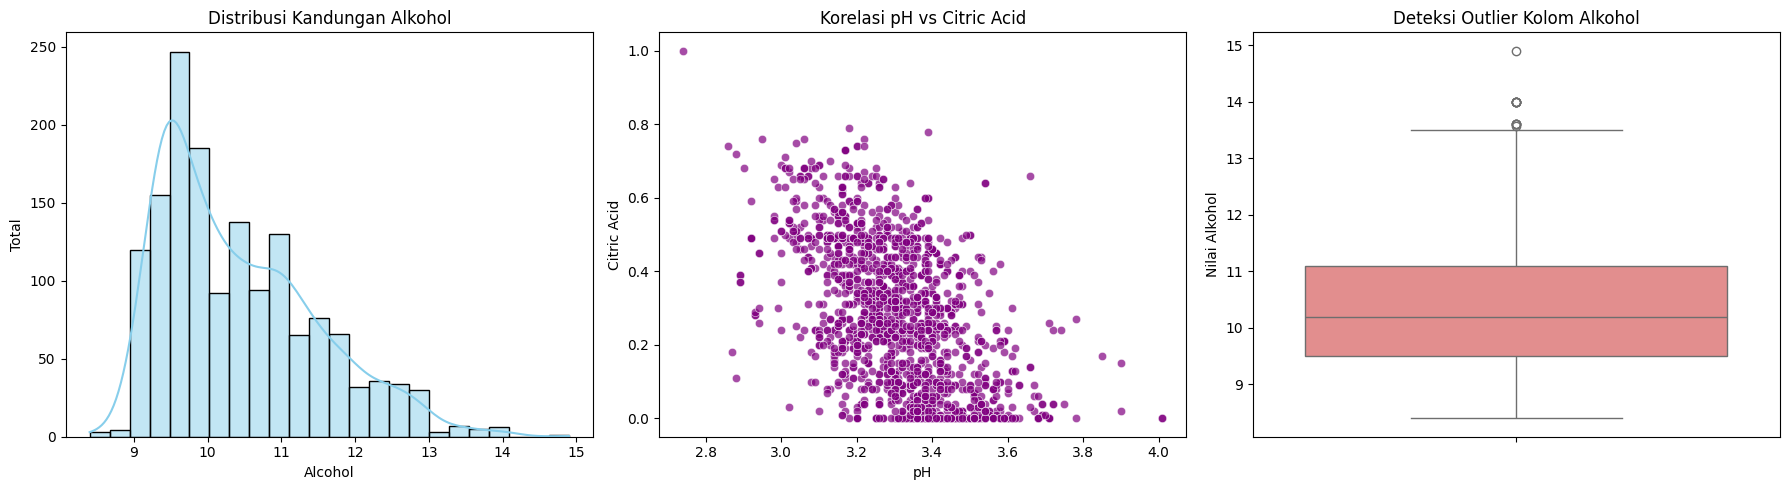

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Struktur Data ---")
df_raw.info()

print("\n--- Deskripsi Statistik ---")
print(df_raw[['pH', 'alcohol', 'density', 'citric acid']].describe())

print("\n--- Cek Data Kosong ---")
print(df_raw.isnull().sum())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df_raw, x='alcohol', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Kandungan Alkohol')
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Total')

sns.scatterplot(data=df_raw, x='pH', y='citric acid', alpha=0.7, ax=axes[1], color='purple')
axes[1].set_title('Korelasi pH vs Citric Acid')
axes[1].set_xlabel('pH')
axes[1].set_ylabel('Citric Acid')

sns.boxplot(data=df_raw, y='alcohol', ax=axes[2], color='lightcoral')
axes[2].set_title('Deteksi Outlier Kolom Alkohol')
axes[2].set_ylabel('Nilai Alkohol')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [19]:
df_pre = df_raw.drop_duplicates().copy()

df_pre['alcohol'] = df_pre['alcohol'].fillna(df_pre['alcohol'].median())
df_pre['pH'] = df_pre['pH'].fillna(df_pre['pH'].mean())

Q1 = df_pre['alcohol'].quantile(0.25)
Q3 = df_pre['alcohol'].quantile(0.75)
IQR = Q3 - Q1
df_pre['alcohol'] = np.where(df_pre['alcohol'] > (Q3 + 1.5 * IQR), (Q3 + 1.5 * IQR), df_pre['alcohol'])
df_pre['alcohol'] = np.where(df_pre['alcohol'] < (Q1 - 1.5 * IQR), (Q1 - 1.5 * IQR), df_pre['alcohol'])

In [20]:
df_pre['pH_group'] = np.where(df_pre['pH'] < 3.3, 'Asam', 'Normal')

# Mengubah target quality menjadi biner (1 = Baik jika skor >= 6, 0 = Kurang Baik jika skor < 6)
y = np.where(df_pre['quality'] >= 6, 1, 0)
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH_group', 'sulphates', 'alcohol']
X = df_pre[features].copy()

X['pH_group'] = LabelEncoder().fit_transform(X['pH_group'])

numeric_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol']
X[numeric_cols] = StandardScaler().fit_transform(X[numeric_cols])

In [21]:
df_clean = X.copy()
df_clean['target'] = y

df_raw.to_csv("wine_raw.csv", index=False)
df_clean.to_csv("wine_preprocessed.csv", index=False)

print("Proses preprocessing Wine Dataset selesai.")

Proses preprocessing Wine Dataset selesai.
